In [ ]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math
import os
import re
import json
import numpy as np

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
# data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

matplotlib 识别的字体名: Songti SC


In [247]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))

In [248]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df

In [249]:
# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

    
    # filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
    # print("清洗后的列名:", filtered_df.columns.tolist())

In [250]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [ ]:
def train(X_train, y_train, X_val, y_val):
    # 定义 Optuna 目标函数
    def objective(trial):
        # 建议超参数范围
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
            'random_state': 42
        }
        
        # 创建模型
        model = RandomForestClassifier(**params)
        
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测验证集概率
        y_val_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # 计算 AUC
        auc_score = roc_auc_score(y_val, y_val_pred_proba)
        
        # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
        return 1.0 - auc_score

    # 创建 Optuna 研究
    study = optuna.create_study(
        direction='minimize',  # 最小化目标函数 (1 - AUC)
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
    )

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")
    best_params = best_trial.params
    best_params['random_state'] = 42

    final_model = RandomForestClassifier(**best_params)
    final_model.fit(X_train, y_train)
     
    return [final_model,best_params]

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name):
    # y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # 最佳阈值
    best_thresh, best_auc = 0.5, 0
    for thresh in np.arange(0.1, 0.65, 0.05):
        pred_val = (y_pred_proba > thresh).astype(int)
        f1 = roc_auc_score(y, pred_val)
        if f1 > best_auc:
            best_thresh, best_auc = thresh, f1

    print(f"最佳阈值: {best_thresh:.2f}，测试集最大auc: {best_auc:.4f}")

    y_pred = (y_pred_proba >= best_thresh).astype(int)


    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred_proba)
    
    res_auc = bootstrap_auc_ci(y, y_pred_proba, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")

    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }


In [252]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])
    
    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/RF/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)

    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - RF ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/RF/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/RF_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'RF_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'RF_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'RF_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'RF_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'RF_Dataset{current_dataset}'][model] = data_to_append

    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)

In [ ]:
def draw_shap(final_model, X_train, X_test, current_dataset, key):
    task_trans = {
        "阴性组vs其他": "NG vs Others",
        "细菌性脑膜炎vs其他感染性脑膜炎": "Infectious Meningitis vs Non-Infectious ",
        "细菌性脑膜炎vs其他感染性脑膜炎": "ABM vs Other Infectious Meningitis",
        "病毒性脑膜炎vs其他感染性脑膜炎": "VM vs Other Infectious Meningitis",
        "结核性脑膜炎vs其他感染性脑膜炎": "TBM vs Other Infectious Meningitis",
        "真菌性脑膜炎vs其他感染性脑膜炎": "FM vs Other Infectious Meningitis",
        "肿瘤性脑膜炎vs其他": "LMD vs Others",
        "自身免疫性脑膜炎vs其他": "AM vs Others",
        "病毒性脑膜炎vs病毒性脑炎": "VM vs VE"
    }

    # ---------------- SHAP 分析 -----------------
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test)
    shap_values = shap_values[:, :, 1]
    # shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

    trans_df = pd.read_excel('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/ipynb/项目英文缩写与全称.xlsx')
    trans_dict = {}

    for index, row in trans_df.iterrows():
        trans_dict[row['中文项目名称']] = row['英文缩写']
    # new_index = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for x in list(X_test.columns)]
    X_test = X_test.rename(columns={'血_葡萄糖空腹_定量': '血_葡萄糖[空腹]_定量'})
    X_test = X_test.rename(columns={'血_肌酸激酶.MB型质量法_定量': '血_肌酸激酶.MB型[质量法]_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD3-CD19+百分比_定量': '血_细胞.CD3-CD19+百分比_定量'})   
    X_test = X_test.rename(columns={'血_13-β-D-葡聚糖_定量': '血_1,3-β-D-葡聚糖_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD3+CD8+百分比_定量': '血_细胞.CD3+CD8+百分比_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD3+CD4+百分比_定量': '血_细胞.CD3+CD4+百分比_定量'})   
    
    X_test.columns = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for i, x in enumerate(X_test.columns)]
     
    X_test_en = X_test.rename(columns=trans_dict)
    feature_names_en = list(X_test_en.columns)

    print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
    plt.title(f"Features' Importance of {task_trans[key]} (Histogram)", fontsize=18, fontweight='bold')
    plt.tight_layout()
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=feature_names_en)
    # plt.gca().invert_xaxis()
    # for p in plt.gca().patches:            # 柱子是 patch
    #     p.set_alpha(0.3) 
    # plt.gca().tick_params(axis='both', labelsize=22)
    # for lab in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    #     lab.set_fontweight('bold') 
    # for r in plt.gca().patches:     # 每个 r 是一个 Rectangle
    #     r.set_height(0.9) 
    # plt.xlabel("mean(|SHAP value|)", fontsize=22, fontweight='bold')
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/RF/shap/Dataset{current_dataset}/{key}shap柱状图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    plt.title(f"Features' Importance of {task_trans[key]} (Beeswarm Plot)", fontsize=18, fontweight='bold')
    plt.tight_layout()

    print(f"\n===== SHAP 特征分布 (蜂群图): =====")
    # max_display = 20
    # h = 0.5 * max_display + 1   # 经验公式：每个特征 ~0.5 英寸
    shap.summary_plot(shap_values, X_test, show=False, feature_names=feature_names_en, plot_size=(9, h))
    # plt.gca().tick_params(axis='both', labelsize=22)
    # for lab in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    #     lab.set_fontweight('bold') 
    # plt.xlabel("SHAP value", fontsize=22, fontweight='bold')
    # # 画布与坐标轴背景透明
    # fig = plt.gcf()
    # fig.patch.set_alpha(0.0)              # 整个画布透明
    # for ax in fig.axes:
    #     ax.set_facecolor('none')          # 每个子图（含色条）背景透明

    # cbar_ax = fig.axes[-1]                 # 通常最后一个就是colorbar的轴
    # cbar_ax.tick_params(labelsize=20)      # 刻度字号
    # for lab in cbar_ax.get_yticklabels():
    #     lab.set_fontweight('bold')         # 刻度加粗
    # for coll in plt.gca().collections:                 # PathCollection
    #     try:
    #         coll.set_sizes([30])                # 数值越大点越大
    #     except Exception:
    #         pass
    # # 如果要把右侧的“Feature value”文字也放大加粗：
    # cbar_ax.set_ylabel("Feature value", fontsize=22, fontweight='bold')
    # plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/RF/shap/Dataset{current_dataset}/{key}shap蜂群图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

[I 2025-11-13 16:04:00,608] A new study created in memory with name: no-name-732a16df-6fc1-482b-9cee-6803df3af248


开始超参数优化...


Best trial: 0. Best value: 0.154181:   1%|          | 1/100 [00:00<00:36,  2.70it/s]

[I 2025-11-13 16:04:01,027] Trial 0 finished with value: 0.15418118466898956 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.15418118466898956.


Best trial: 0. Best value: 0.154181:   2%|▏         | 2/100 [00:02<02:12,  1.36s/it]

...

[I 2025-11-13 16:04:57,003] Trial 94 finished with value: 0.12020905923344949 and parameters: {'n_estimators': 100, 'max_depth': 27, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 47 with value: 0.11149825783972123.
[I 2025-11-13 16:04:57,137] Trial 95 finished with value: 0.11178861788617889 and parameters: {'n_estimators': 100, 'max_depth': 26, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 47 with value: 0.11149825783972123.


Best trial: 47. Best value: 0.111498:  97%|█████████▋| 97/100 [00:57<00:01,  2.21it/s]

[I 2025-11-13 16:04:58,267] Trial 96 finished with value: 0.14837398373983735 and parameters: {'n_estimators': 100, 'max_depth': 25, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 47 with value: 0.11149825783972123.


Best trial: 47. Best value: 0.111498: 100%|██████████| 100/100 [00:58<00:00,  1.72it/s]


[I 2025-11-13 16:04:58,513] Trial 97 finished with value: 0.12195121951219512 and parameters: {'n_estimators': 150, 'max_depth': 26, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 47 with value: 0.11149825783972123.
[I 2025-11-13 16:04:58,577] Trial 98 finished with value: 0.1286295005807201 and parameters: {'n_estimators': 50, 'max_depth': 27, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 47 with value: 0.11149825783972123.
[I 2025-11-13 16:04:58,700] Trial 99 finished with value: 0.12020905923344949 and parameters: {'n_estimators': 100, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 47 with value: 0.11149825783972123.

优化完成!
Number of finished tria

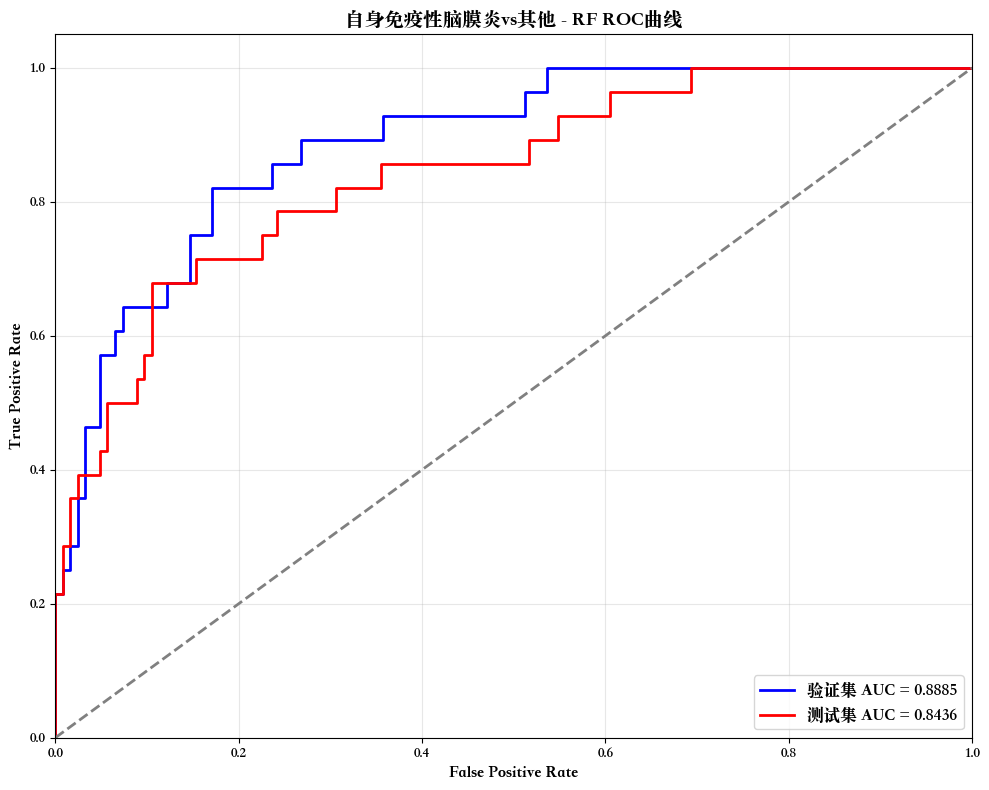


===== SHAP 特征重要性 (柱状图):  =====


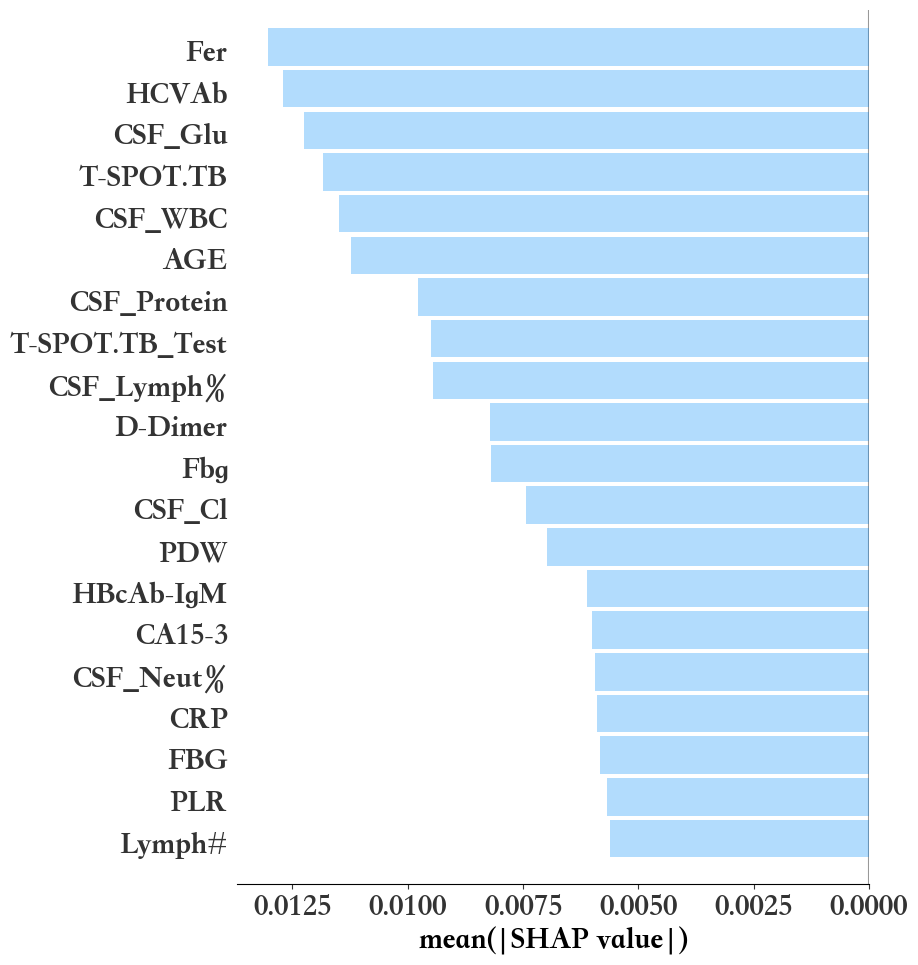


===== SHAP 特征分布 (蜂群图): =====


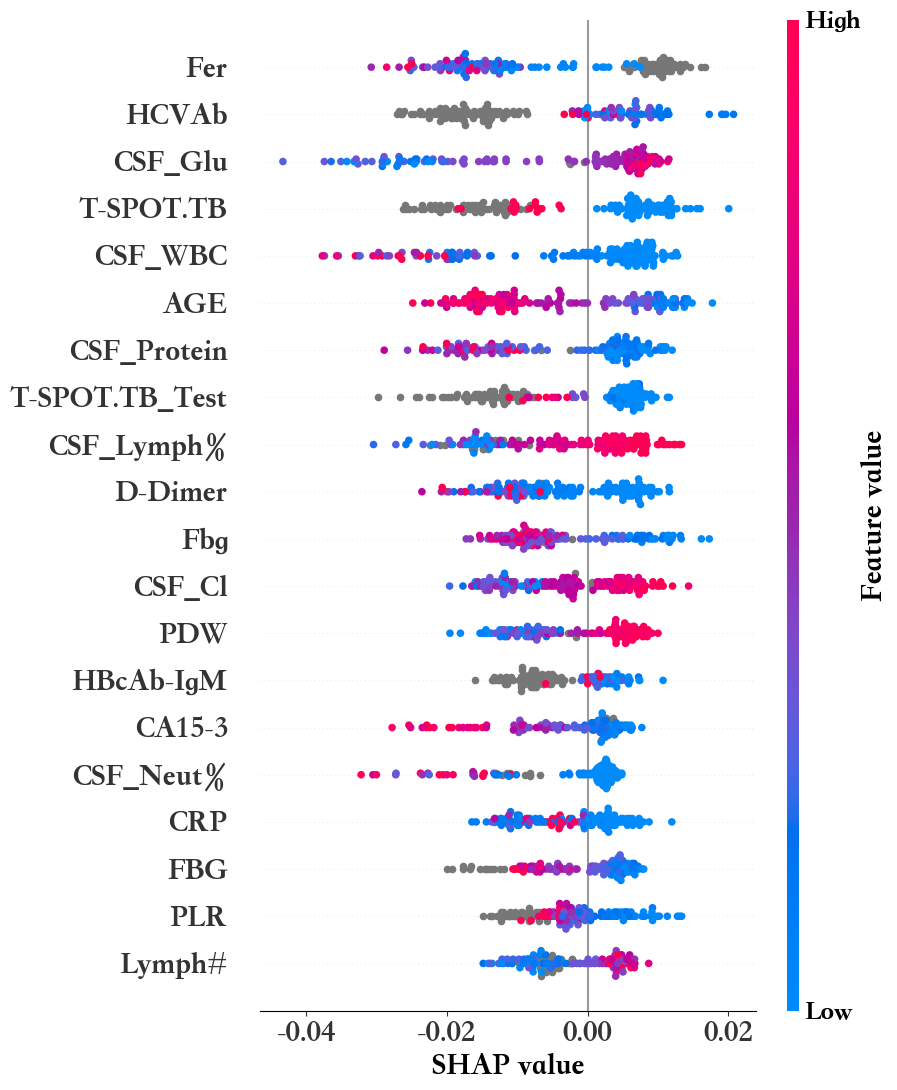

In [ ]:
filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎vs非感染性脑膜炎': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

def run_model(key, item, selected_df, current_dataset):
    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]

    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    # 得到最优模型
    result = train(X_train, y_train, X_val, y_val)
    final_model = result[0]
    # 评估验证集和测试集
    val_results = evaluate_model(final_model, X_val, y_val, "验证")
    test_results = evaluate_model(final_model, X_test, y_test, "测试")    
    
    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, val_results, test_results, key, current_dataset)

    # 绘制shap图
    draw_shap(final_model, X_train, X_test, current_dataset, key)
    return result[1]

if extract_integers(data_path)[-1] == 2:
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞.CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞.CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体.IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞.CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    filtered_df2 = filtered_df.copy()
    result_para = run_model(key, item, filtered_df2, current_dataset)

     # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9)
